# Feature Engineering

This notebook covers all feature engineering steps.

For now, data will be taken from an interim csv file, where the data is stored right after loading from DB.

This solution is used only for exploration purposes. If engineered features are useful for the model, they will be introduced as a part of a standard data processing pipeline.

## Steps covered:

- Data loading from csv

- **Feature selection from EDA:**
    - `item_id` — clear product-level heterogeneity
    - `category` — meaningful variance across categories; complements item_id at coarser level
    - `is_outbound` — binary feature with strong effect (outbound flights show ~2x higher conversion than inbound)
    - `sales_hour_bin` — 3 time-of-day groups with ~2.7x variance between peak and low periods
    - `am_pm` — coarser temporal signal
    - `duration_bin` — 4 flight-duration categories; strongest numeric signal
    - `pax_bin` — 6 passenger-capacity groups with clear non-linear trend
    - `price_bin` — 4 price segments; must be interpreted jointly with item_id
    - `route` — hub-based structure; filtered to routes with ≥10 flights

- **Hierarchical aggregation with 5 levels:**
    1. `item × route × sales_hour_bin × duration_bin`
    2. `item × route × duration_bin`
    3. `item × sales_hour_bin × duration_bin`
    4. `item` (all records)
    5. `category` (fallback for rare products)

- **Historical average per passenger per item** (`hist_avg_per_pax`) with fallbacks: `item × pax_bin → item → category`

- **Item trend signal** based on rolling short (10 flights) vs long (60 flights) sales facts

Features that do not demonstrate predictive signal will be excluded from the final pipeline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv("../interim_files/notebooks/df_new.csv", parse_dates=['date'])
print(f"Columns: {df.columns.tolist()}")
print(f"\nTotal records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days}")

## 1. Hierarchical Aggregation Level Analysis

Before implementing the full CV pipeline, let's analyze the coverage and data availability at each aggregation level.

**High level hist_avg coverage check** — quick sanity check on how many unique combinations at each level have at least 5 records:

In [ ]:
level1_coverage = df.groupby(['item_id', 'route', 'sales_hour_bin', 'duration_bin']).size()
print(f"Level 1 (item×route×sales_hour_bin×duration_bin) — coverage %: "
      f"{(level1_coverage >= 5).sum() / len(level1_coverage) * 100:.1f}%")

level2_coverage = df.groupby(['item_id', 'route', 'duration_bin']).size()
print(f"Level 2 (item×route×duration_bin) — coverage %: "
      f"{(level2_coverage >= 5).sum() / len(level2_coverage) * 100:.1f}%")

level3_coverage = df.groupby(['item_id', 'sales_hour_bin', 'duration_bin']).size()
print(f"Level 3 (item×sales_hour_bin×duration_bin) — coverage %: "
      f"{(level3_coverage >= 5).sum() / len(level3_coverage) * 100:.1f}%")

### Level 1: `item_id × route × sales_hour_bin × duration_bin`

- **Risk**: Not enough records for rare combinations
- **Advantage**: Most specific — captures route-specific and time-of-day patterns

In [16]:
item_route_hour_duration_df = df.groupby(
    ['item_id', 'route', 'sales_hour_bin', 'duration_bin']
)['sold_quantity'].agg(['mean', 'sum', 'count'])

total_groups = len(item_route_hour_duration_df)
groups_below_5 = len(item_route_hour_duration_df[item_route_hour_duration_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 1: item_id × route × sales_hour_bin × duration_bin")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 5: {groups_below_5}")
print(f"  Percentage below 5: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥5 samples: {100 - percent_below_5:.2f}%")

Level 1: item_id × route × sales_hour_bin × duration_bin
  Total groups: 1315
  Groups with count < 5: 450
  Percentage below 5: 34.22%
  → Coverage with ≥5 samples: 65.78%


**Conclusion**: A combination of `item_id × route × sales_hour_bin × duration_bin` provides enough datapoints for most unique combinations with at least 5 records. Rare combinations will be handled via fallback levels below.

### Level 2: `item_id × route × duration_bin`

- **Risk**: No time-of-day indication
- **Advantage**: Better coverage, useful fallback when Level 1 has insufficient data

In [17]:
item_route_duration_df = df.groupby(
    ['item_id', 'route', 'duration_bin', 'day_period']
)['sold_quantity'].agg(['mean', 'sum', 'count'])

total_groups = len(item_route_duration_df)
groups_below_5 = len(item_route_duration_df[item_route_duration_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 2: item_id × route × duration_bin")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 5: {groups_below_5}")
print(f"  Percentage below 5: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥5 samples: {100 - percent_below_5:.2f}%")

Level 2: item_id × route × duration_bin
  Total groups: 1230
  Groups with count < 5: 340
  Percentage below 5: 27.64%
  → Coverage with ≥5 samples: 72.36%


**Conclusion**: A combination of `item_id × route × duration_bin` provides notably better coverage than Level 1 and serves as a reliable fallback for rare time-of-day combinations.

### Level 3: `item_id × sales_hour_bin × duration_bin`

- **Risk**: Loses route-specific signal
- **Advantage**: Better coverage, useful fallback when Level 2 has insufficient data

In [18]:
item_hour_duration_df = df.groupby(
    ['item_id', 'sales_hour_bin', 'duration_bin']
)['sold_quantity'].agg(['mean', 'sum', 'count'])

total_groups = len(item_hour_duration_df)
groups_below_5 = len(item_hour_duration_df[item_hour_duration_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 3: item_id × sales_hour_bin × duration_bin")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 5: {groups_below_5}")
print(f"  Percentage below 5: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥5 samples: {100 - percent_below_5:.2f}%")

Level 3: item_id × sales_hour_bin × duration_bin
  Total groups: 160
  Groups with count < 5: 10
  Percentage below 5: 6.25%
  → Coverage with ≥5 samples: 93.75%


**Conclusion**: A combination of `item_id × sales_hour_bin × duration_bin` provides near-full coverage — useful for records where both Level 1 and Level 2 have insufficient data.

### Level 4: `item_id`

- **Risk**: The least granular item-level view — only avg by item_id
- **Advantage**: 100% coverage for items already seen in training

*Level 5 (category-level) will be used inside the CV function as an ultimate fallback for items that are absent from the training fold entirely.*

In [19]:
item_only_df = df.groupby(['item_id'])['sold_quantity'].agg(['mean', 'sum', 'count'])

total_groups = len(item_only_df)
print(f"Level 4: item_id only")
print(f"  Total groups: {total_groups}")
print(f"  → 100% coverage by definition; used as the last item-specific fallback")

Level 4: item_id only
  Total groups: 10
  → 100% coverage by definition; used as the last item-specific fallback


## 2. Blocked Cross-Validation Setup

**Strategy**: Expanding window cross-validation with 14-day validation blocks.

**Logic**:

- First 14 days used as initial training set
- Each fold validates on next 14-day block
- Training window expands with each fold (includes all previous data)
- Last fold may be partial if remaining data < 14 days
- Ensures no data leakage: features computed only from past data

In [20]:
df = df.sort_values('date').reset_index(drop=True)

print("Sorted dataframe by date (required for fold indices to work correctly)")
print(f"  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  Total records: {len(df)}")

Sorted dataframe by date (required for fold indices to work correctly)
  Date range: 2025-11-01 to 2026-02-28
  Total records: 59370


In [21]:
def create_blocked_cv_folds(df, block_size_days=14):
    """
    Create blocked cross-validation folds with expanding window.
    Includes last partial fold if remaining data exists.

    Parameters
    ----------
    df : DataFrame
        Data with 'date' column
    block_size_days : int
        Size of each validation block in days (default: 14)

    Returns
    -------
    list of fold dictionaries
    """
    df = df.sort_values('date').reset_index(drop=True)
    min_date = df['date'].min()
    max_date = df['date'].max()

    folds = []
    current_date = min_date

    while current_date < max_date:
        val_start = current_date
        val_end = min(current_date + timedelta(days=block_size_days), max_date + timedelta(days=1))

        train_mask = df['date'] < val_start
        val_mask = (df['date'] >= val_start) & (df['date'] < val_end)

        if train_mask.sum() > 0 and val_mask.sum() > 0:
            folds.append({
                'fold_num': len(folds) + 1,
                'train_start': df[train_mask]['date'].min(),
                'train_end': df[train_mask]['date'].max(),
                'val_start': val_start,
                'val_end': val_end - timedelta(days=1),
                'train_indices': df[train_mask].index.tolist(),
                'val_indices': df[val_mask].index.tolist(),
                'train_size': train_mask.sum(),
                'val_size': val_mask.sum()
            })

        current_date += timedelta(days=block_size_days)

    return folds

In [22]:
# Create folds
folds = create_blocked_cv_folds(df, block_size_days=14)

print(f"\nCreated {len(folds)} folds from dataframe:")
print("="*100)
for fold in folds:
    print(f"Fold {fold['fold_num']}: Train [{fold['train_start'].date()} to {fold['train_end'].date()}] "
          f"→ Val [{fold['val_start'].date()} to {fold['val_end'].date()}] | "
          f"Train size: {fold['train_size']}, Val size: {fold['val_size']}")


Created 8 folds from dataframe:
Fold 1: Train [2025-11-01 to 2025-11-14] → Val [2025-11-15 to 2025-11-28] | Train size: 6770, Val size: 6895
Fold 2: Train [2025-11-01 to 2025-11-28] → Val [2025-11-29 to 2025-12-12] | Train size: 13665, Val size: 7095
Fold 3: Train [2025-11-01 to 2025-12-12] → Val [2025-12-13 to 2025-12-26] | Train size: 20760, Val size: 7060
Fold 4: Train [2025-11-01 to 2025-12-26] → Val [2025-12-27 to 2026-01-09] | Train size: 27820, Val size: 7100
Fold 5: Train [2025-11-01 to 2026-01-09] → Val [2026-01-10 to 2026-01-23] | Train size: 34920, Val size: 7040
Fold 6: Train [2025-11-01 to 2026-01-23] → Val [2026-01-24 to 2026-02-06] | Train size: 41960, Val size: 6940
Fold 7: Train [2025-11-01 to 2026-02-06] → Val [2026-02-07 to 2026-02-20] | Train size: 48900, Val size: 6690
Fold 8: Train [2025-11-01 to 2026-02-20] → Val [2026-02-21 to 2026-02-28] | Train size: 55590, Val size: 3780


## 3. Hierarchical Feature Engineering Function

**Objective**: Compute historical average sales for each record using hierarchical aggregation, plus a per-passenger average with its own fallback chain.

**Hierarchy (from most to least granular)**:

1. **Level 1**: `item_id × route × sales_hour_bin × duration_bin`
2. **Level 2**: `item_id × route × duration_bin`
3. **Level 3**: `item_id × sales_hour_bin × duration_bin`
4. **Level 4**: `item_id`
5. **Level 5**: `category` (used if item_id is missing from training fold)

**Per-passenger average** (`hist_avg_per_pax`) with fallbacks:

- Primary: `item_id × pax_bin`
- Fallback 1: `item_id`
- Fallback 2: `category`

**Output columns**:

- `hist_avg`: single feature with historical average value
- `hist_level_used`: indicator (1–5) showing which level was used
- `hist_avg_per_pax`: sales-per-passenger historical average

In [23]:
def compute_hierarchical_historical_avg(train_df, val_df, min_samples=5):
    """
    Compute hierarchical historical average for validation set.

    Parameters
    ----------
    train_df : DataFrame
        Training data
    val_df : DataFrame
        Validation data
    min_samples : int
        Minimum samples required at each level to use that average

    Returns
    -------
    DataFrame with historical average features added
    """
    val_df = val_df.copy()

    # ------------------------------------------------------------------
    # HIST_AVG: hierarchical levels (1–5)
    # ------------------------------------------------------------------

    # Level 1: item_id × route × sales_hour_bin × duration_bin
    level1_avg = train_df.groupby(['item_id', 'route', 'sales_hour_bin', 'duration_bin']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level1_avg.columns = ['hist_avg_l1', 'hist_count_l1']
    level1_avg = level1_avg.reset_index()

    # Level 2: item_id × route × duration_bin
    level2_avg = train_df.groupby(['item_id', 'route', 'duration_bin']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level2_avg.columns = ['hist_avg_l2', 'hist_count_l2']
    level2_avg = level2_avg.reset_index()

    # Level 3: item_id × sales_hour_bin × duration_bin
    level3_avg = train_df.groupby(['item_id', 'sales_hour_bin', 'duration_bin']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level3_avg.columns = ['hist_avg_l3', 'hist_count_l3']
    level3_avg = level3_avg.reset_index()

    # Level 4: item_id
    level4_avg = train_df.groupby(['item_id']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level4_avg.columns = ['hist_avg_l4', 'hist_count_l4']
    level4_avg = level4_avg.reset_index()

    # Level 5: category (fallback for items missing from training fold)
    level5_avg = train_df.groupby(['category']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level5_avg.columns = ['hist_avg_l5', 'hist_count_l5']
    level5_avg = level5_avg.reset_index()

    # ------------------------------------------------------------------
    # HIST_AVG_PER_PAX: average per passenger with fallbacks
    # ------------------------------------------------------------------

    # Primary: item_id × pax_bin
    pax_avg = train_df.groupby(['item_id', 'pax_bin']).agg({
        'sold_quantity': 'sum',
        'number_of_passengers': 'sum'
    })
    pax_avg['hist_avg_per_pax'] = pax_avg['sold_quantity'] / pax_avg['number_of_passengers']
    pax_avg = pax_avg.reset_index()[['item_id', 'pax_bin', 'hist_avg_per_pax']]

    # Fallback 1: item_id (no pax_bin)
    item_avg_per_pax = train_df.groupby(['item_id']).agg({
        'sold_quantity': 'sum',
        'number_of_passengers': 'sum'
    })
    item_avg_per_pax['hist_avg_per_pax_item'] = (
        item_avg_per_pax['sold_quantity'] / item_avg_per_pax['number_of_passengers']
    )
    item_avg_per_pax = item_avg_per_pax.reset_index()[['item_id', 'hist_avg_per_pax_item']]

    # Fallback 2: category
    category_avg_per_pax = train_df.groupby(['category']).agg({
        'sold_quantity': 'sum',
        'number_of_passengers': 'sum'
    })
    category_avg_per_pax['hist_avg_per_pax_category'] = (
        category_avg_per_pax['sold_quantity'] / category_avg_per_pax['number_of_passengers']
    )
    category_avg_per_pax = category_avg_per_pax.reset_index()[['category', 'hist_avg_per_pax_category']]

    # ------------------------------------------------------------------
    # Merge hist_avg levels
    # ------------------------------------------------------------------
    val_df = val_df.merge(level1_avg, on=['item_id', 'route', 'sales_hour_bin', 'duration_bin'], how='left')
    val_df = val_df.merge(level2_avg, on=['item_id', 'route', 'duration_bin'], how='left')
    val_df = val_df.merge(level3_avg, on=['item_id', 'sales_hour_bin', 'duration_bin'], how='left')
    val_df = val_df.merge(level4_avg, on=['item_id'], how='left')
    val_df = val_df.merge(level5_avg, on=['category'], how='left')

    # Merge hist_avg_per_pax levels
    val_df = val_df.merge(pax_avg, on=['item_id', 'pax_bin'], how='left')
    val_df = val_df.merge(item_avg_per_pax, on=['item_id'], how='left')
    val_df = val_df.merge(category_avg_per_pax, on=['category'], how='left')

    # ------------------------------------------------------------------
    # Hierarchical fallback logic for HIST_AVG
    # ------------------------------------------------------------------
    val_df['hist_avg'] = np.nan
    val_df['hist_level_used'] = np.nan

    # Level 1
    mask_l1 = (val_df['hist_count_l1'] >= min_samples)
    val_df.loc[mask_l1, 'hist_avg'] = val_df.loc[mask_l1, 'hist_avg_l1']
    val_df.loc[mask_l1, 'hist_level_used'] = 1

    # Level 2
    mask_l2 = (val_df['hist_avg'].isna()) & (val_df['hist_count_l2'] >= min_samples)
    val_df.loc[mask_l2, 'hist_avg'] = val_df.loc[mask_l2, 'hist_avg_l2']
    val_df.loc[mask_l2, 'hist_level_used'] = 2

    # Level 3
    mask_l3 = (val_df['hist_avg'].isna()) & (val_df['hist_count_l3'] >= min_samples)
    val_df.loc[mask_l3, 'hist_avg'] = val_df.loc[mask_l3, 'hist_avg_l3']
    val_df.loc[mask_l3, 'hist_level_used'] = 3

    # Level 4
    mask_l4 = (val_df['hist_avg'].isna()) & (val_df['hist_count_l4'] >= min_samples)
    val_df.loc[mask_l4, 'hist_avg'] = val_df.loc[mask_l4, 'hist_avg_l4']
    val_df.loc[mask_l4, 'hist_level_used'] = 4

    # Level 5 (category)
    mask_l5 = (val_df['hist_avg'].isna())
    val_df.loc[mask_l5, 'hist_avg'] = val_df.loc[mask_l5, 'hist_avg_l5']
    val_df.loc[mask_l5, 'hist_level_used'] = 5

    # ------------------------------------------------------------------
    # Fallback logic for HIST_AVG_PER_PAX: item×pax_bin → item → category
    # ------------------------------------------------------------------
    val_df['hist_avg_per_pax'] = val_df['hist_avg_per_pax'].fillna(val_df['hist_avg_per_pax_item'])
    val_df['hist_avg_per_pax'] = val_df['hist_avg_per_pax'].fillna(val_df['hist_avg_per_pax_category'])

    val_df = val_df.drop(columns=['hist_avg_per_pax_item', 'hist_avg_per_pax_category'])

    # ------------------------------------------------------------------
    # Coverage
    # ------------------------------------------------------------------
    coverage = (~val_df['hist_avg'].isna()).sum() / len(val_df) * 100
    level_usage = val_df['hist_level_used'].value_counts().sort_index()

    return val_df, coverage, level_usage

## 4. Apply Features to All CV Folds

Loop through all folds, compute hierarchical features, and track:

- Coverage % (records with features)
- Level usage distribution per fold
- Add `fold_num` column to track which fold each record belongs to

In [24]:
# Apply hierarchical historical averages to all CV folds
results = []
all_val_dfs = []

for fold in folds:
    train_indices = fold['train_indices']
    val_indices = fold['val_indices']

    train_df = df.iloc[train_indices]
    val_df = df.iloc[val_indices]

    # Compute features
    val_with_features, coverage, level_usage = compute_hierarchical_historical_avg(
        train_df, val_df, min_samples=5
    )

    val_with_features['fold_num'] = fold['fold_num']

    results.append({
        'fold_num': fold['fold_num'],
        'coverage': coverage,
        'level_usage': level_usage
    })

    all_val_dfs.append(val_with_features)

    print(f"Fold {fold['fold_num']}: Coverage = {coverage:.2f}%")
    print(f"  Level usage: {level_usage.to_dict()}")
    print()

# Concatenate all folds into one dataframe
all_folds_data = pd.concat(all_val_dfs, ignore_index=True)
print(f"\nComplete CV dataset shape: {all_folds_data.shape}")
print(f"Date range: {all_folds_data['date'].min().date()} to {all_folds_data['date'].max().date()}")

Fold 1: Coverage = 100.00%
  Level usage: {1.0: 5985, 2.0: 670, 3.0: 240}

Fold 2: Coverage = 100.00%
  Level usage: {1.0: 6725, 2.0: 370}

Fold 3: Coverage = 100.00%
  Level usage: {1.0: 6935, 2.0: 125}

Fold 4: Coverage = 100.00%
  Level usage: {1.0: 7010, 2.0: 90}

Fold 5: Coverage = 100.00%
  Level usage: {1.0: 6970, 2.0: 70}

Fold 6: Coverage = 100.00%
  Level usage: {1.0: 6655, 2.0: 285}

Fold 7: Coverage = 100.00%
  Level usage: {1.0: 6625, 2.0: 65}

Fold 8: Coverage = 100.00%
  Level usage: {1.0: 3700, 2.0: 80}


Complete CV dataset shape: (52600, 42)
Date range: 2025-11-15 to 2026-02-28


In [25]:
# checking hist_avg_per_pax coverage across all folds
if 'hist_avg_per_pax' in all_folds_data.columns:
    print("Column hist_avg_per_pax exists")
else:
    print("Column hist_avg_per_pax not found")
    print(f"Available columns: {all_folds_data.columns.tolist()}")

nan_count = all_folds_data['hist_avg_per_pax'].isna().sum()
total = len(all_folds_data)
coverage_pct = (1 - nan_count / total) * 100
print(f"Coverage:")
print(f"  Total records: {total:,}")
print(f"  NaN values:    {nan_count:,}")
print(f"  Coverage:      {coverage_pct:.2f}%")

print(f"\nStatistics hist_avg_per_pax:")
print(all_folds_data['hist_avg_per_pax'].describe())

corr = all_folds_data[['hist_avg', 'hist_avg_per_pax', 'sold_quantity']].corr()
print(f"\nCorrelation")
print(corr)

Column hist_avg_per_pax exists
Coverage:
  Total records: 52,600
  NaN values:    0
  Coverage:      100.00%

Statistics hist_avg_per_pax:
count    52600.000000
mean         0.004349
std          0.003817
min          0.000000
25%          0.002516
50%          0.003401
75%          0.004210
max          0.023658
Name: hist_avg_per_pax, dtype: float64

Correlation
                  hist_avg  hist_avg_per_pax  sold_quantity
hist_avg          1.000000          0.507120       0.730621
hist_avg_per_pax  0.507120          1.000000       0.369469
sold_quantity     0.730621          0.369469       1.000000


## 5. Feature Quality Visualization

Four-panel visualization showing:

1. **Coverage by Fold**: Feature availability % per fold (target: >90%)
2. **Hierarchy Level Usage**: Total usage count for each aggregation level
3. **Level Distribution by Fold**: Stacked bars showing level usage evolution across folds
4. **Coverage Trend**: Line chart tracking coverage stability over time

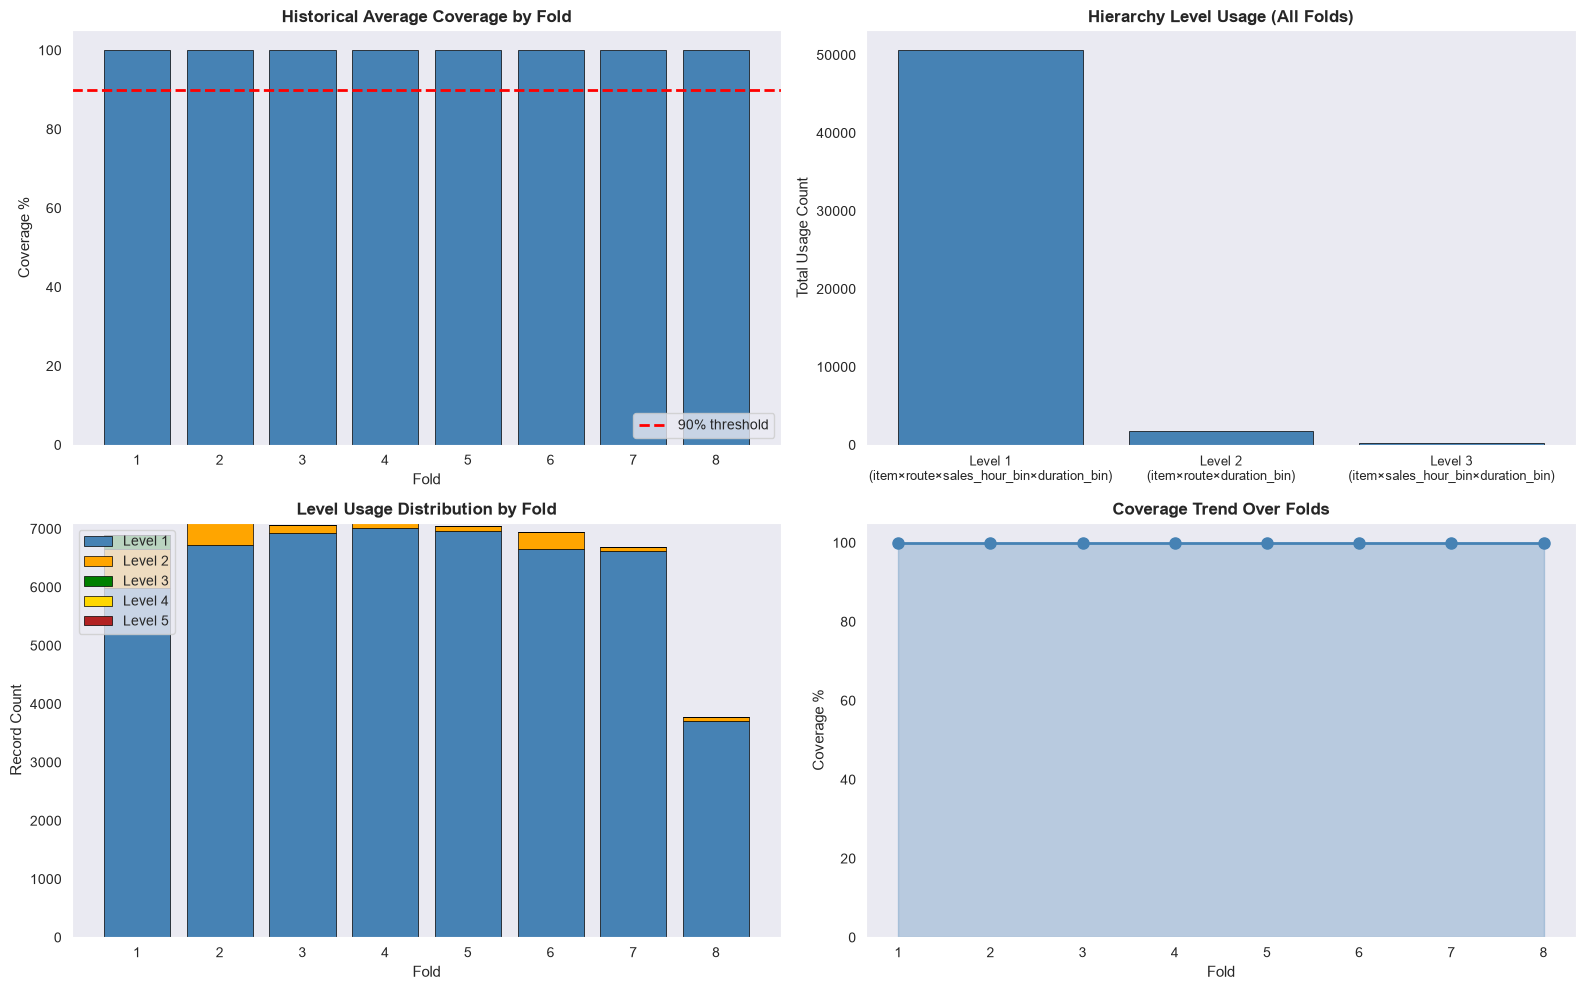


Visualization saved to: assests/feature_quality_analysis.png


In [26]:
# Feature Quality Analysis - Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Historical Average Coverage by Fold (top left)
ax1 = axes[0, 0]
coverage_by_fold = [r['coverage'] for r in results]
folds_list = [r['fold_num'] for r in results]
ax1.bar(folds_list, coverage_by_fold, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.axhline(y=90, color='red', linestyle='--', linewidth=2, label='90% threshold')
ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('Coverage %', fontsize=11)
ax1.set_title('Historical Average Coverage by Fold', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 105])
ax1.legend(loc='lower right')
ax1.grid(False)

# 2. Hierarchy Level Usage - All Folds (top right)
ax2 = axes[0, 1]
level_counts = all_folds_data['hist_level_used'].value_counts().sort_index()

level_titles = {
    1: 'item×route×sales_hour_bin×duration_bin',
    2: 'item×route×duration_bin',
    3: 'item×sales_hour_bin×duration_bin',
    4: 'item',
    5: 'category'
}
labels = [f"Level {int(lvl)}\n({level_titles.get(int(lvl), '')})" for lvl in level_counts.index]
ax2.bar(range(len(level_counts)), level_counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(level_counts)))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Total Usage Count', fontsize=11)
ax2.set_title('Hierarchy Level Usage (All Folds)', fontsize=12, fontweight='bold')
ax2.grid(False)

# 3. Level Usage Distribution by Fold (bottom left)
ax3 = axes[1, 0]
fold_level_data = []
for fold_num in sorted(all_folds_data['fold_num'].unique()):
    fold_data = all_folds_data[all_folds_data['fold_num'] == fold_num]
    level_dist = fold_data['hist_level_used'].value_counts().sort_index()
    fold_level_data.append({
        'fold': fold_num,
        'level_1': level_dist.get(1, 0),
        'level_2': level_dist.get(2, 0),
        'level_3': level_dist.get(3, 0),
        'level_4': level_dist.get(4, 0),
        'level_5': level_dist.get(5, 0),
    })

fold_level_df = pd.DataFrame(fold_level_data)
x_pos = fold_level_df['fold']
ax3.bar(x_pos, fold_level_df['level_1'], label='Level 1', color='steelblue', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_2'], bottom=fold_level_df['level_1'],
        label='Level 2', color='orange', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_3'],
        bottom=fold_level_df['level_1'] + fold_level_df['level_2'],
        label='Level 3', color='green', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_4'],
        bottom=fold_level_df['level_1'] + fold_level_df['level_2'] + fold_level_df['level_3'],
        label='Level 4', color='gold', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_5'],
        bottom=fold_level_df['level_1'] + fold_level_df['level_2']
               + fold_level_df['level_3'] + fold_level_df['level_4'],
        label='Level 5', color='firebrick', edgecolor='black', linewidth=0.5)
ax3.set_xlabel('Fold', fontsize=11)
ax3.set_ylabel('Record Count', fontsize=11)
ax3.set_title('Level Usage Distribution by Fold', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(False)

# 4. Coverage Trend Over Folds (bottom right)
ax4 = axes[1, 1]
ax4.plot(folds_list, coverage_by_fold, marker='o', linewidth=2, markersize=8, color='steelblue')
ax4.fill_between(folds_list, 0, coverage_by_fold, alpha=0.3, color='steelblue')
ax4.set_xlabel('Fold', fontsize=11)
ax4.set_ylabel('Coverage %', fontsize=11)
ax4.set_title('Coverage Trend Over Folds', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 105])
ax4.grid(False)

plt.tight_layout()
plt.savefig('assests/feature_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: assests/feature_quality_analysis.png")

## Computing items trend

Compare recent vs. historical sales behavior per item to capture emerging trends:

- **Short window**: last 10 flights per item (excluding current)
- **Long window**: last 60 flights per item (excluding current)
- **Raw trend**: share of last sales in the historical baseline (`f_short / (f_long + 0.01)`)
- If the absolute difference between short and long windows is below **15%**, treat as noise and set trend to `1.0` (stable)
- **Trend classification** (`trend_signal`):
    - `CRITICAL_DROP` — no recent sales at all
    - `SLOW_DROP` — below-baseline recent activity
    - `STABLE` — within noise band
    - `GROWTH` — moderate increase (1.0–1.7x)
    - `AGGRESSIVE_GROWTH` — sharp increase (> 1.7x)

In [27]:
all_folds_data = all_folds_data.sort_values(by=['item_id', 'date']).reset_index(drop=True)

all_folds_data['sales_fact'] = (all_folds_data['sold_quantity'] > 0).astype(int)

# short (10 last flights, excluding current)
all_folds_data['f_short'] = all_folds_data.groupby('item_id')['sales_fact'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=3).mean()
)

# long-term historical (60 last flights, excluding current)
all_folds_data['f_long'] = all_folds_data.groupby('item_id')['sales_fact'].transform(
    lambda x: x.shift(1).rolling(window=60, min_periods=10).mean()
)

# Fill early records (no history yet) with global sales_fact mean
all_folds_data['f_short'] = all_folds_data['f_short'].fillna(all_folds_data['sales_fact'].mean())
all_folds_data['f_long'] = all_folds_data['f_long'].fillna(all_folds_data['sales_fact'].mean())

# Raw trend as share of short-term signal in long-term baseline
all_folds_data['raw_trend'] = all_folds_data['f_short'] / (all_folds_data['f_long'] + 0.01)

# Threshold logic: if diff between short and long is below THRESHOLD → treat as noise (stable = 1.0)
THRESHOLD = 0.15
all_folds_data['item_trend_with_threshold'] = np.where(
    np.abs(all_folds_data['f_short'] - all_folds_data['f_long']) > THRESHOLD,
    all_folds_data['raw_trend'],
    1.0
)

all_folds_data = all_folds_data.drop(columns=['sales_fact', 'f_short', 'f_long', 'raw_trend'])
print(all_folds_data['item_trend_with_threshold'].describe())

count    52600.000000
mean         1.007185
std          0.329211
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.488372
Name: item_trend_with_threshold, dtype: float64


In [28]:
conditions = [
    (all_folds_data['item_trend_with_threshold'] == 0.0),
    (all_folds_data['item_trend_with_threshold'] < 1.0) & (all_folds_data['item_trend_with_threshold'] > 0.0),
    (all_folds_data['item_trend_with_threshold'] == 1.0),
    (all_folds_data['item_trend_with_threshold'] > 1.0) & (all_folds_data['item_trend_with_threshold'] <= 1.7),
    (all_folds_data['item_trend_with_threshold'] > 1.7),
]
choices = ['CRITICAL_DROP', 'SLOW_DROP', 'STABLE', 'GROWTH', 'AGGRESSIVE_GROWTH']
all_folds_data['trend_signal'] = np.select(conditions, choices, default='STABLE')
print(all_folds_data['trend_signal'].value_counts())

trend_signal
STABLE               38734
SLOW_DROP             5751
GROWTH                5348
AGGRESSIVE_GROWTH     1918
CRITICAL_DROP          849
Name: count, dtype: int64


## 6. Save Complete Dataset

Save all CV folds with engineered features to CSV.

**Output**: `complete_data_with_features.csv` containing:

- All original columns
- `hist_avg`: historical average feature
- `hist_level_used`: aggregation level (1–5)
- `hist_avg_per_pax`: per-passenger historical average
- `item_trend_with_threshold`: rolling short/long trend
- `trend_signal`: categorical trend classification
- `fold_num`: cross-validation fold identifier
- Intermediate level columns (`hist_avg_l1..l5`, `hist_count_l1..l5`)

In [29]:
# Save complete dataset with features
all_folds_data.to_csv("../interim_files/notebooks/complete_data_with_features.csv", index=False)

print(f"Saved complete CV dataset with features")
print(f"  File: interim_files/complete_data_with_features.csv")
print(f"  Shape: {all_folds_data.shape}")
print(f"  Columns: {list(all_folds_data.columns)}")

Saved complete CV dataset with features
  File: interim_files/complete_data_with_features.csv
  Shape: (52600, 44)
  Columns: ['Unnamed: 0', 'flight_key', 'flight_number', 'origin', 'destination', 'date', 'month_name', 'year', 'weekday_name', 'is_weekend', 'hour_of_departure', 'day_period', 'is_night', 'am_pm', 'number_of_passengers', 'item_id', 'category', 'price', 'is_outbound', 'flight_duration_hours', 'sold_quantity', 'potential_error', 'flight_duration_round', 'route', 'pax_bin', 'price_bin', 'sales_hour_bin', 'duration_bin', 'hist_avg_l1', 'hist_count_l1', 'hist_avg_l2', 'hist_count_l2', 'hist_avg_l3', 'hist_count_l3', 'hist_avg_l4', 'hist_count_l4', 'hist_avg_l5', 'hist_count_l5', 'hist_avg_per_pax', 'hist_avg', 'hist_level_used', 'fold_num', 'item_trend_with_threshold', 'trend_signal']
